
# Notebook 05 — Modelo Informer: entrenamiento y optimizacion de hiperparametros

Este notebook implementa y entrena el modelo **Informer** (Zhou et al., 2021) para la prediccion de irradiancia solar (RS) a partir de los artefactos generados en el Notebook 04 (`data_norm.npy`, `marcas_temp.npy`, escaladores y `config_fe.pkl`).

**Articulacion con la Actividad 3.** Se evalua un mismo modelo bajo distintas variantes, en dos ejes:

- **Grupos de variables (ablacion):** V1 autorregresivo (RS + ciclos temporales), V2 con variables meteorologicas de NASA POWER y V3 completo (incluyendo los productos satelitales de irradiancia ALLSKY, CLRSKY y el indice de claridad KT). La comparacion cuantifica el aporte marginal de NASA POWER, nucleo de la justificacion metodologica del proyecto (Taha, Makeen & Nazih, 2025).
- **Horizonte de prediccion:** 1 h, 3 h y 6 h.

**Alcance de este notebook (05):** motor de entrenamiento, optimizacion de hiperparametros con evidencia empirica (tabla y figura) y seleccion de la configuracion definitiva. El entrenamiento final de todas las variantes/horizontes, las metricas de desempeno (MAE, RMSE, R2, sMAPE), las figuras de prediccion frente a observacion y la comparacion con la linea base de persistencia se desarrollan en el **Notebook 06**.

**Arquitectura de referencia:** se emplea la implementacion oficial del Informer (repositorio `zhouhaoyi/Informer2020`), construyendo alrededor de ella el motor de entrenamiento propio, articulado con la clase `InformerDataset` del Notebook 04.

In [ ]:
# 1. Configuracion del entorno
!pip install torch numpy pandas matplotlib scikit-learn --quiet

import os, sys, gc, time, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP     = torch.cuda.is_available()   # precision mixta solo en GPU; si hubiera error de tipo, fijar en False

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# MODO de ejecucion:
#   'piloto'   -> stride alto y pocas epocas: valida el flujo completo en minutos
#   'completo' -> stride bajo y mas epocas: corrida definitiva para el documento
MODO = 'completo'

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
print('AMP     :', USE_AMP)
print('MODO    :', MODO)

PyTorch : 2.11.0+cu128
Device  : cuda
AMP     : True
MODO    : completo


In [ ]:
# 2. Montaje de Google Drive y resolucion de rutas
# Los artefactos del Notebook 04 se localizan mediante 'find' para evitar
# los problemas de rutas con tildes ya documentados en el proyecto.
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive ya montado.')

res = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'config_fe.pkl'],
    capture_output=True, text=True, timeout=240
)
rutas = [r for r in res.stdout.strip().split('\n') if r]
if not rutas:
    raise FileNotFoundError('No se encontro config_fe.pkl. Ejecute primero el Notebook 04.')

RUTA_ARRAYS = os.path.dirname(
    next((r for r in rutas if any(k in r for k in ['Maestr', 'Codigos', 'Trabajo', 'arrays'])), rutas[0])
)
RUTA_DATOS   = os.path.dirname(RUTA_ARRAYS)
RUTA_BASE    = os.path.dirname(RUTA_DATOS)
RUTA_MODELOS = os.path.join(RUTA_BASE, 'modelos')
RUTA_FIGS    = os.path.join(RUTA_BASE, 'figuras')
RUTA_RES     = os.path.join(RUTA_BASE, 'resultados')
for d in (RUTA_MODELOS, RUTA_FIGS, RUTA_RES):
    os.makedirs(d, exist_ok=True)

print('RUTA_ARRAYS  :', RUTA_ARRAYS)
print('RUTA_MODELOS :', RUTA_MODELOS)
print('RUTA_RES     :', RUTA_RES)

Mounted at /content/drive
RUTA_ARRAYS  : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos/arrays
RUTA_MODELOS : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/modelos
RUTA_RES     : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/resultados


In [ ]:
# 3. Modelo de referencia: implementacion oficial del Informer
# Zhou et al. (2021), "Informer: Beyond Efficient Transformer for Long
# Sequence Time-Series Forecasting", AAAI. Repositorio: zhouhaoyi/Informer2020.
# Se reutiliza la arquitectura oficial (atencion ProbSparse, destilacion del
# codificador y decodificacion generativa) y se construye alrededor de ella
# el motor de entrenamiento propio, articulado con el Dataset del Notebook 04.
REPO_INFORMER = '/content/Informer2020'
if not os.path.exists(REPO_INFORMER):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/zhouhaoyi/Informer2020.git',
                    REPO_INFORMER], check=True)
if REPO_INFORMER not in sys.path:
    sys.path.append(REPO_INFORMER)

from models.model import Informer
print('Arquitectura Informer importada correctamente.')

Arquitectura Informer importada correctamente.


In [ ]:
# 4. Carga de artefactos del Notebook 04
data_norm   = np.load(os.path.join(RUTA_ARRAYS, 'data_norm.npy'))
marcas_temp = np.load(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'))
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'rb') as f:
    config = pickle.load(f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'rb') as f:
    scaler_rs = pickle.load(f)

VARS_ENTRADA  = list(config['vars_entrada'])
VAR_OBJETIVO  = config['var_objetivo']
IDX_OBJETIVO  = config['idx_objetivo']
SEQ_LEN       = config['seq_len']
LABEL_LEN     = config['label_len']
PRED_LENS     = config['pred_lens']
IDX_TRAIN_END = config['idx_train_end']
IDX_VAL_END   = config['idx_val_end']
N_TOTAL       = config['n_total']

# Factor de desnormalizacion de RS (MinMax): W/m2 = norm * range + min
RS_MIN   = float(scaler_rs.data_min_[0])
RS_RANGE = float(scaler_rs.data_range_[0])

print('data_norm   :', data_norm.shape, data_norm.dtype)
print('marcas_temp :', marcas_temp.shape, marcas_temp.dtype)
print('Variables   :', len(VARS_ENTRADA), '| Objetivo:', VAR_OBJETIVO, '(idx', IDX_OBJETIVO, ')')
print('Particion   : train <', IDX_TRAIN_END, '| val <', IDX_VAL_END, '| total', N_TOTAL)
print('Horizontes  :', PRED_LENS)
print('RS_min      :', round(RS_MIN, 3), '| RS_range:', round(RS_RANGE, 3), 'W/m2')

data_norm   : (1330560, 18) float32
marcas_temp : (1330560, 4) float32
Variables   : 18 | Objetivo: RS (idx 0 )
Particion   : train < 931391 | val < 1130975 | total 1330560
Horizontes  : {'1h': 12, '3h': 36, '6h': 72}
RS_min      : 0.0 | RS_range: 1524.0 W/m2


## Variantes por grupos de variables

La comparacion entre variantes responde a una pregunta metodologica concreta: cuanto mejora la prediccion de RS al incorporar progresivamente informacion de NASA POWER. Se definen tres grupos anidados:

- **V1 — autorregresivo:** RS y sus ciclos temporales (hora, dia del anio, mes). Linea base endogena que solo usa la propia serie y la estacionalidad.
- **V2 — meteorologico NASA:** agrega variables meteorologicas y astronomicas de NASA POWER (T2M, RH2M, precipitacion, viento en componentes u/v, presion y angulo cenital solar), sin incluir aun la irradiancia satelital.
- **V3 — completo:** agrega los productos satelitales de irradiancia (ALLSKY, CLRSKY) y el indice de claridad (KT).

El caracter anidado de los grupos permite atribuir las diferencias de desempeno al bloque de variables incorporado en cada paso. RS se mantiene como primera columna en los tres grupos, de modo que su indice dentro del subconjunto es siempre 0.

In [ ]:
# 6. Definicion de las variantes por grupos de variables
GRUPOS_VARIABLES = {
    'V1_autorregresivo': [
        'RS', 'sin_hora', 'cos_hora',
        'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
    ],
    'V2_meteo_nasa': [
        'RS', 'sin_hora', 'cos_hora',
        'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
        'T2M', 'RH2M', 'PRECTOTCORR',
        'WS10M', 'WD10M_u', 'WD10M_v', 'PS', 'SZA',
    ],
    'V3_completo': list(VARS_ENTRADA),
}

def columnas_variante(nombre_variante):
    # Indices de columna en data_norm para la variante dada.
    # RS se ubica siempre en la posicion 0 del subconjunto.
    nombres = GRUPOS_VARIABLES[nombre_variante]
    return [VARS_ENTRADA.index(v) for v in nombres]

print('Variantes definidas:')
for k, v in GRUPOS_VARIABLES.items():
    print(f'  {k:<20} -> {len(v):>2} variables')

Variantes definidas:
  V1_autorregresivo    ->  7 variables
  V2_meteo_nasa        -> 15 variables
  V3_completo          -> 18 variables


## Construccion de DataLoaders y submuestreo temporal

A 5 minutos de resolucion, dos ventanas consecutivas comparten 287 de 288 pasos de contexto: son casi identicas. Entrenar sobre la totalidad de las ventanas es redundante y multiplica el costo sin aportar informacion proporcional. Por ello se aplica un submuestreo por `stride`: se toma una de cada `stride` ventanas, reduciendo el tiempo de entrenamiento de forma sustancial y conservando la cobertura de todo el periodo. La particion temporal (sin mezclar) y la ausencia de fuga de informacion se heredan del Notebook 04.

In [ ]:
# 8. Clase InformerDataset (identica a la del Notebook 04, autocontenida)
# Indexacion dinamica: cada muestra se extrae por slicing del array en RAM,
# sin materializar ventanas estaticas. Estructura de cada muestra:
#   enc_input (seq_len, n_vars) | enc_mark (seq_len, 4)
#   dec_input (label_len+pred_len, n_vars) con el objetivo enmascarado en el futuro
#   dec_mark  (label_len+pred_len, 4) | target (pred_len,)
class InformerDataset(Dataset):
    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data         = data
        self.marcas       = marcas
        self.seq_len      = seq_len
        self.label_len    = label_len
        self.pred_len     = pred_len
        self.idx_objetivo = idx_objetivo
        self._inicio = max(idx_inicio, seq_len)
        self._fin    = min(idx_fin, len(data) - pred_len)
        self._len    = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        t = self._inicio + i
        enc_input = self.data[t - self.seq_len : t, :]
        enc_mark  = self.marcas[t - self.seq_len : t, :]
        dec_start = t - self.label_len
        dec_end   = t + self.pred_len
        dec_input = self.data[dec_start : dec_end, :].copy()
        dec_mark  = self.marcas[dec_start : dec_end, :]
        dec_input[self.label_len:, self.idx_objetivo] = 0.0
        target = self.data[t : t + self.pred_len, self.idx_objetivo]
        return (
            torch.from_numpy(enc_input),
            torch.from_numpy(enc_mark),
            torch.from_numpy(dec_input),
            torch.from_numpy(dec_mark),
            torch.from_numpy(target),
        )

print('Clase InformerDataset definida.')

Clase InformerDataset definida.


In [ ]:
# 9. Construccion de DataLoaders por variante y horizonte
def build_loaders(nombre_variante, nombre_horizonte,
                  stride_train, stride_eval, batch_size, num_workers=2):
    # Nota: si en Colab aparecen errores de multiprocessing, usar num_workers=0.
    cols     = columnas_variante(nombre_variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])   # (N, k) float32
    pred_len = PRED_LENS[nombre_horizonte]
    enc_in   = data_sub.shape[1]

    splits = [
        ('train', 0,             IDX_TRAIN_END, stride_train),
        ('val',   IDX_TRAIN_END, IDX_VAL_END,   stride_eval),
        ('test',  IDX_VAL_END,   N_TOTAL,       stride_eval),
    ]
    loaders, tam = {}, {}
    for split, i_ini, i_fin, stride in splits:
        ds_full = InformerDataset(
            data_sub, marcas_temp, i_ini, i_fin,
            SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0
        )
        idx = list(range(0, len(ds_full), stride))
        ds  = Subset(ds_full, idx)
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=num_workers, pin_memory=USE_AMP,
            drop_last=(split == 'train')
        )
        tam[split] = len(ds)
    return loaders, enc_in, pred_len, tam

print('Funcion build_loaders definida.')

Funcion build_loaders definida.


## Constructor del modelo

Se configura el Informer en modo multivariante a univariante (MS): el codificador y el decodificador reciben todas las variables de la variante (`enc_in = dec_in`) y la capa de proyeccion final entrega una unica salida, RS (`c_out = 1`). Se conservan los mecanismos caracteristicos del Informer: atencion ProbSparse (`attn='prob'`), destilacion del codificador (`distil=True`) y decodificacion generativa mediante el prefijo conocido `label_len` mas el horizonte enmascarado. El embebido temporal `timeF` proyecta linealmente las 4 marcas temporales [mes, dia, dia de la semana, hora] al espacio del modelo, lo que es compatible con `marcas_temp`.

In [ ]:
# 11. Constructor del modelo Informer (modo MS: multivariante -> univariante)
def build_informer(enc_in, pred_len, hp):
    model = Informer(
        enc_in=enc_in, dec_in=enc_in, c_out=1,
        seq_len=SEQ_LEN, label_len=LABEL_LEN, out_len=pred_len,
        factor=hp['factor'], d_model=hp['d_model'], n_heads=hp['n_heads'],
        e_layers=hp['e_layers'], d_layers=hp['d_layers'], d_ff=hp['d_ff'],
        dropout=hp['dropout'], attn='prob', embed='timeF', freq='h',
        activation='gelu', output_attention=False, distil=True, mix=True,
        device=DEVICE
    ).to(DEVICE)
    return model

def contar_parametros(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Funcion build_informer definida.')

Funcion build_informer definida.


## Motor de entrenamiento

La estrategia de entrenamiento es comun a todas las variantes para garantizar comparaciones en igualdad de condiciones: perdida MSE en el espacio normalizado, optimizador Adam con regularizacion L2 leve, reduccion de la tasa de aprendizaje al estancarse la validacion, recorte de la norma del gradiente y parada temprana (early stopping) sobre la perdida de validacion. En GPU se activa precision mixta (AMP) para acelerar el computo. Si en algun entorno la precision mixta produjera errores de tipo, basta con fijar `USE_AMP = False` en la primera celda.

In [ ]:
# 13. Motor de entrenamiento: evaluacion de perdida y ciclo de entrenamiento
def _mover(batch):
    enc, enc_m, dec, dec_m, tgt = batch
    return (enc.to(DEVICE), enc_m.to(DEVICE),
            dec.to(DEVICE), dec_m.to(DEVICE), tgt.to(DEVICE))

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out  = model(enc, enc_m, dec, dec_m).squeeze(-1)   # (B, pred_len)
            loss = criterion(out, tgt)
        total += loss.item() * tgt.size(0)
        n     += tgt.size(0)
    return total / max(n, 1)

def train_model(model, loaders, max_epochs=15, lr=5e-4, weight_decay=1e-4,
                patience=4, clip=1.0, ruta_ckpt=None, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2)
    scaler = GradScaler(DEVICE_TYPE, enabled=USE_AMP)

    historia = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val = float('inf')
    sin_mejora = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        t0, suma, n = time.time(), 0.0, 0
        for batch in loaders['train']:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            optimizer.zero_grad(set_to_none=True)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out  = model(enc, enc_m, dec, dec_m).squeeze(-1)
                loss = criterion(out, tgt)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer)
            scaler.update()
            suma += loss.item() * tgt.size(0)
            n    += tgt.size(0)

        train_loss = suma / max(n, 1)
        val_loss   = evaluate_loss(model, loaders['val'], criterion)
        scheduler.step(val_loss)
        lr_actual  = optimizer.param_groups[0]['lr']

        historia['train_loss'].append(train_loss)
        historia['val_loss'].append(val_loss)
        historia['lr'].append(lr_actual)

        if verbose:
            print(f'  Epoca {epoch:>2}/{max_epochs} | train {train_loss:.5e} | '
                  f'val {val_loss:.5e} | lr {lr_actual:.1e} | {time.time()-t0:.1f}s')

        if val_loss < best_val - 1e-7:
            best_val, sin_mejora = val_loss, 0
            if ruta_ckpt is not None:
                torch.save(model.state_dict(), ruta_ckpt)
        else:
            sin_mejora += 1
            if sin_mejora >= patience:
                if verbose:
                    print(f'  Parada temprana en epoca {epoch} (sin mejora en {patience} epocas).')
                break

    return best_val, historia

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


In [ ]:
# 14. Prueba de humo (smoke test)
# Verifica de extremo a extremo tensores, modelo y ciclo de entrenamiento
# con un modelo pequeno y muy pocas ventanas (debe correr en pocos minutos).
hp_prueba = dict(factor=5, d_model=128, n_heads=4, e_layers=2,
                 d_layers=1, d_ff=128, dropout=0.05)

loaders_t, enc_in_t, pred_len_t, tam_t = build_loaders(
    'V3_completo', '1h', stride_train=200, stride_eval=200, batch_size=32)
print('Tamanos (smoke):', tam_t, '| enc_in:', enc_in_t)

modelo_t = build_informer(enc_in_t, pred_len_t, hp_prueba)
print('Parametros entrenables:', f'{contar_parametros(modelo_t):,}')

best_v, hist_t = train_model(modelo_t, loaders_t, max_epochs=2, lr=5e-4,
                             patience=2, ruta_ckpt=None, verbose=True)
print('Smoke test OK. Mejor val:', f'{best_v:.5e}')

del modelo_t, loaders_t
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Tamanos (smoke): {'train': 4656, 'val': 998, 'test': 998} | enc_in: 18
Parametros entrenables: 430,593
  Epoca  1/2 | train 3.91338e-02 | val 1.42218e-02 | lr 5.0e-04 | 9.1s
  Epoca  2/2 | train 7.36424e-03 | val 1.14686e-02 | lr 5.0e-04 | 5.5s
Smoke test OK. Mejor val: 1.14686e-02


## Optimizacion de hiperparametros

La optimizacion se realiza mediante busqueda aleatoria sobre la variante mas informativa (V3) y el horizonte mas corto (1 h), por ser el de entrenamiento mas rapido. Cada configuracion se entrena unas pocas epocas con parada temprana y se evalua por su perdida de validacion. La mejor configuracion se fija y se reutiliza para entrenar todas las variantes y horizontes en el Notebook 06, manteniendo la comparacion entre variantes en igualdad de condiciones. La busqueda aleatoria es preferible a la exhaustiva en espacios de varios hiperparametros, pues alcanza buenas configuraciones evaluando muchas menos combinaciones. La tabla `resultados/hpo_resultados.csv` y la figura `figuras/hpo_val_loss.png` constituyen la evidencia empirica de la optimizacion exigida en la Actividad 3.

In [ ]:
# 16. Optimizacion de hiperparametros (busqueda aleatoria sobre V3, horizonte 1h)
ESPACIO_HP = {
    'd_model' : [128, 256, 512],
    'n_heads' : [4, 8],
    'e_layers': [2, 3],
    'd_layers': [1, 2],
    'd_ff'    : [128, 256, 512],
    'dropout' : [0.05, 0.10, 0.15],
    'factor'  : [3, 5],
    'lr'      : [1e-3, 5e-4, 1e-4],
}

if MODO == 'piloto':
    N_CONFIGS, HPO_STRIDE_TRAIN, HPO_STRIDE_EVAL, HPO_EPOCHS, BATCH = 4, 60, 60, 3, 64
else:
    N_CONFIGS, HPO_STRIDE_TRAIN, HPO_STRIDE_EVAL, HPO_EPOCHS, BATCH = 12, 18, 24, 6, 64

rng = np.random.default_rng(SEED)
def muestrear_hp():
    return {k: rng.choice(v).item() for k, v in ESPACIO_HP.items()}

loaders_hpo, enc_in_hpo, pred_len_hpo, tam_hpo = build_loaders(
    'V3_completo', '1h',
    stride_train=HPO_STRIDE_TRAIN, stride_eval=HPO_STRIDE_EVAL, batch_size=BATCH)
print('Ventanas HPO:', tam_hpo, '| enc_in:', enc_in_hpo)
print('=' * 70)

registros, vistas = [], set()
for i in range(N_CONFIGS):
    hp = muestrear_hp()
    while (tuple(hp.items()) in vistas) or (hp['d_model'] % hp['n_heads'] != 0):
        hp = muestrear_hp()
    vistas.add(tuple(hp.items()))

    lr = hp.pop('lr')
    print(f'[{i+1}/{N_CONFIGS}] d_model={hp["d_model"]} heads={hp["n_heads"]} '
          f'e={hp["e_layers"]} d={hp["d_layers"]} d_ff={hp["d_ff"]} '
          f'drop={hp["dropout"]} factor={hp["factor"]} lr={lr:.0e}')
    t0     = time.time()
    modelo = build_informer(enc_in_hpo, pred_len_hpo, hp)
    n_par  = contar_parametros(modelo)
    best_v, _ = train_model(modelo, loaders_hpo, max_epochs=HPO_EPOCHS,
                            lr=lr, patience=2, ruta_ckpt=None, verbose=False)
    dur = time.time() - t0
    registros.append({**hp, 'lr': lr, 'n_parametros': n_par,
                      'val_loss': best_v, 'segundos': round(dur, 1)})
    print(f'      -> val_loss={best_v:.5e} | params={n_par:,} | {dur:.1f}s')
    del modelo
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

df_hpo = pd.DataFrame(registros).sort_values('val_loss').reset_index(drop=True)
df_hpo.to_csv(os.path.join(RUTA_RES, 'hpo_resultados.csv'), index=False)
print('=' * 70)
print('Resultados de la busqueda (ordenados por val_loss):')
print(df_hpo.to_string(index=False))

Ventanas HPO: {'train': 51728, 'val': 8316, 'test': 8316} | enc_in: 18
[1/12] d_model=128 heads=8 e=3 d=1 d_ff=256 drop=0.15 factor=3 lr=1e-04
      -> val_loss=6.68200e-03 | params=711,297 | 273.2s
[2/12] d_model=128 heads=4 e=3 d=2 d_ff=512 drop=0.15 factor=5 lr=1e-04
      -> val_loss=6.74427e-03 | params=1,239,041 | 353.2s
[3/12] d_model=256 heads=4 e=3 d=1 d_ff=256 drop=0.1 factor=3 lr=1e-04
      -> val_loss=6.57169e-03 | params=2,273,537 | 308.7s
[4/12] d_model=512 heads=8 e=2 d=2 d_ff=256 drop=0.1 factor=3 lr=1e-03
      -> val_loss=6.90090e-03 | params=8,217,601 | 811.5s
[5/12] d_model=128 heads=8 e=3 d=1 d_ff=512 drop=0.15 factor=3 lr=5e-04
      -> val_loss=6.50178e-03 | params=974,465 | 281.8s
[6/12] d_model=128 heads=8 e=3 d=1 d_ff=128 drop=0.15 factor=3 lr=1e-04
      -> val_loss=6.72362e-03 | params=579,713 | 285.4s
[7/12] d_model=512 heads=8 e=3 d=1 d_ff=256 drop=0.1 factor=3 lr=1e-03
      -> val_loss=9.16431e-03 | params=7,953,921 | 714.3s
[8/12] d_model=256 heads=4 e

Mejor configuracion (val_loss = 6.42978e-03):
  d_model   : 256
  n_heads   : 4
  e_layers  : 3
  d_layers  : 1
  d_ff      : 128
  dropout   : 0.05
  factor    : 5
  lr        : 0.0001


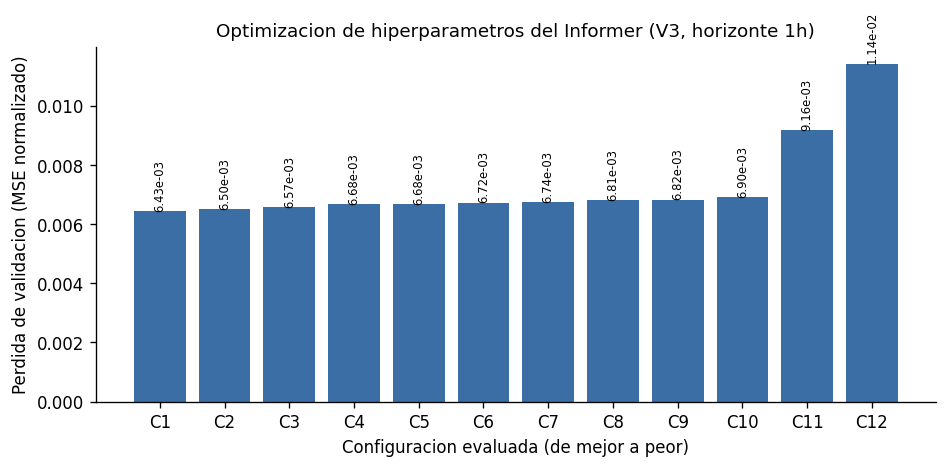

Figura guardada    : figuras/hpo_val_loss.png
Config. guardada   : resultados/hp_best.pkl
Tabla guardada     : resultados/hpo_resultados.csv


In [ ]:
# 17. Seleccion y registro de la mejor configuracion
mejor = df_hpo.iloc[0].to_dict()
enteros = ['d_model', 'n_heads', 'e_layers', 'd_layers', 'd_ff', 'factor']
HP_BEST = {k: (int(mejor[k]) if k in enteros else float(mejor[k]))
           for k in ['d_model', 'n_heads', 'e_layers', 'd_layers', 'd_ff', 'dropout', 'factor', 'lr']}

with open(os.path.join(RUTA_RES, 'hp_best.pkl'), 'wb') as f:
    pickle.dump(HP_BEST, f)

print('Mejor configuracion (val_loss = %.5e):' % mejor['val_loss'])
for k, v in HP_BEST.items():
    print(f'  {k:<10}: {v}')

# Evidencia grafica de la optimizacion
fig, ax = plt.subplots(figsize=(8, 4))
etiquetas = [f'C{i+1}' for i in range(len(df_hpo))]
ax.bar(etiquetas, df_hpo['val_loss'].values, color='#3b6ea5')
ax.set_ylabel('Perdida de validacion (MSE normalizado)')
ax.set_xlabel('Configuracion evaluada (de mejor a peor)')
ax.set_title('Optimizacion de hiperparametros del Informer (V3, horizonte 1h)')
for i, v in enumerate(df_hpo['val_loss'].values):
    ax.text(i, v, f'{v:.2e}', ha='center', va='bottom', fontsize=7, rotation=90)
plt.tight_layout()
fig.savefig(os.path.join(RUTA_FIGS, 'hpo_val_loss.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada    : figuras/hpo_val_loss.png')
print('Config. guardada   : resultados/hp_best.pkl')
print('Tabla guardada     : resultados/hpo_resultados.csv')

## Resumen y siguiente paso

Al ejecutar este notebook se obtienen tres artefactos para el documento y para el Notebook 06:

- `resultados/hpo_resultados.csv` — tabla de configuraciones evaluadas y su perdida de validacion.
- `figuras/hpo_val_loss.png` — evidencia grafica de la optimizacion.
- `resultados/hp_best.pkl` — configuracion de hiperparametros seleccionada.

**Notebook 06 — Evaluacion y comparacion de variantes** consumira `hp_best.pkl` para: (1) entrenar el Informer en las 3 variantes x 3 horizontes con la configuracion fija, guardando los pesos en `modelos/` y las curvas de aprendizaje; (2) calcular metricas en unidades fisicas (W/m2) sobre el conjunto de prueba, desnormalizando con `scaler_rs` y aplicando una mascara diurna para las metricas porcentuales; (3) comparar contra una linea base de persistencia; y (4) generar las figuras de prediccion frente a observacion, dispersion y curvas de aprendizaje.

**Recomendacion de ejecucion:** correr primero con `MODO = 'piloto'` para validar el flujo completo en pocos minutos; una vez confirmado, cambiar a `MODO = 'completo'` para la corrida definitiva.